## Autocorrelation of a Unit Pulse

Autocorrelation measures the similarity of a signal with a time-shifted version of itself.  
For a signal $n(t)$, the autocorrelation function is defined as:

$$
R(\tau) = \int_{-\infty}^{\infty} u(t + \tau)u^*(t)\, dt
$$

In this interactive example:

- The **left panel** shows a unit pulse $u(t)$ and its shifted version $u(t + \tau)$.
- The **right panel** shows the autocorrelation function $R(\tau)$.
- Moving the slider changes $\tau$, highlighting the point on the autocorrelation curve that corresponds to the current shift.

This illustrates how the overlap between the signal and its shifted copy determines the autocorrelation value.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Time axis (centered around 0)
fs = 5000
t = np.linspace(-0.02, 0.02, int(fs*0.04), endpoint=False)  # from -0.02 to 0.02 s

# Unit pulse: starts at t=0, ends at t=width
def unit_pulse(t, width=0.004):
    return np.where((t >= 0) & (t < width), 1, 0)

# Autocorrelation function
def autocorr(signal, t):
    dt = t[1] - t[0]
    r = np.correlate(signal, signal, mode='full') * dt
    tau = np.arange(-len(t)+1, len(t)) * dt
    return tau, r

# Original signal
width = 0.01
x = unit_pulse(t, width=width)
tau_vals, Rxx = autocorr(x, t)

def plot_autocorr_interactive(tau_slider=0.0):
    # Shifted signal (positive tau shifts right)
    x_shifted = unit_pulse(t - tau_slider, width=width)
    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    # --- Left: signals with negative t ---
    ax = axes[0]
    ax.plot(t, x, linewidth=2, label='n(t)')
    ax.plot(t, x_shifted, '--', linewidth=2, label=f'n(t+τ), τ={tau_slider:.4f} s')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Amplitude')
    ax.set_title('Unit Pulse and Shifted Version')
    ax.grid(True)
    ax.legend()
    
    # --- Right: autocorrelation ---
    ax2 = axes[1]
    ax2.plot(tau_vals, Rxx, label=r'$R(\tau)$')
    
    # mark the current shift
    idx = (np.abs(tau_vals - tau_slider)).argmin()
    ax2.axvline(tau_slider, color='k', linestyle=':', linewidth=1.5, label='Current τ')
    ax2.plot(tau_vals[idx], Rxx[idx], 'ro', label='Current R')
    
    ax2.set_xlabel('τ [s]')
    ax2.set_ylabel('Autocorrelation')
    ax2.set_title('Autocorrelation Function')
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

interact(
    plot_autocorr_interactive,
    tau_slider=FloatSlider(
        min=-0.02,
        max=0.02,
        step=0.0005,
        value=0.0,
        description='τ [s]'
    )
);


interactive(children=(FloatSlider(value=0.0, description='τ [s]', max=0.02, min=-0.02, step=0.0005), Output())…

### Autocorrelation of a Causal Exponential Signal

For a causal exponential signal

$$
x(t) = A e^{-a t} \, \eta(t), \quad t \ge 0,
$$

where $\eta(t)$ is the unit step function, the **autocorrelation** is defined as

$$
R_{xx}(\tau) = \int_{-\infty}^{\infty} x(t) \, x(t+\tau) \, dt.
$$

For this causal exponential, the analytical result is

$$
R_{xx}(\tau) = \frac{A^2}{2a} \, e^{-a |\tau|}, \quad \tau \in \mathbb{R}.
$$

This shows that the autocorrelation of a decaying exponential is itself an exponential, symmetric around $\tau = 0$, and its width is determined by the decay rate $a$.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Time axis
fs = 5000
t = np.linspace(-0.02, 0.04, int(fs*0.06), endpoint=False)  # longer to include causal signal

# Unit step
def unit_step(t):
    return np.where(t >= 0, 1.0, 0.0)

# Causal exponential signal
def causal_exp(t, A=1.0, a=200):
    return A * np.exp(-a * t) * unit_step(t)

# Autocorrelation function
def autocorr(signal, t):
    dt = t[1] - t[0]
    r = np.correlate(signal, signal, mode='full') * dt
    tau = np.linspace(-t[-1]-dt, t[-1]+dt, len(r))
    return tau, r

# Original signal
A = 1.0
a = 200  # decay rate in 1/s
x = causal_exp(t, A, a)
tau_vals, Rxx = autocorr(x, t)

def plot_autocorr_interactive(tau_slider=0.0, A_val=1.0, a_val=200.0):
    # Update signal with current parameters
    x = causal_exp(t, A=A_val, a=a_val)
    # Shifted signal for visualization
    x_shifted = causal_exp(t + tau_slider, A=A_val, a=a_val)
    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    # --- Left: signals ---
    ax = axes[0]
    ax.plot(t, x, linewidth=2, label='x(t)')
    ax.plot(t, x_shifted, '--', linewidth=2, label=f'x(t+τ), τ={tau_slider:.4f} s')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Amplitude')
    ax.set_title('Causal Exponential Signal and Shifted Version')
    ax.grid(True)
    ax.legend()
    
    # --- Right: autocorrelation ---
    # Recompute autocorrelation with updated parameters
    tau_vals, Rxx = autocorr(x, t)
    ax2 = axes[1]
    ax2.plot(tau_vals, Rxx, label=r'$R(\tau)$')
    ax2.axvline(tau_slider, color='k', linestyle=':', linewidth=1.5, label='Current τ')
    # mark the current value on the curve
    idx = (np.abs(tau_vals - tau_slider)).argmin()
    ax2.plot(tau_vals[idx], Rxx[idx], 'ro', label='Current R')
    
    ax2.set_xlabel('τ [s]')
    ax2.set_ylabel('Autocorrelation')
    ax2.set_title('Autocorrelation Function')
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

interact(
    plot_autocorr_interactive,
    tau_slider=FloatSlider(
        min=-0.02,
        max=0.04,
        step=0.0005,
        value=0.0,
        description='τ [s]'
    ),
    A_val=FloatSlider(
        min=0.1,
        max=2.0,
        step=0.1,
        value=1.0,
        description='A'
    ),
    a_val=FloatSlider(
        min=50,
        max=500,
        step=10,
        value=200,
        description='a [1/s]'
    )
)


interactive(children=(FloatSlider(value=0.0, description='τ [s]', max=0.04, min=-0.02, step=0.0005), FloatSlid…

<function __main__.plot_autocorr_interactive(tau_slider=0.0, A_val=1.0, a_val=200.0)>

### Autocorrelation of harmonic function

We consider a finite-length discrete cosine signal:

$$
x[n] = \cos(\omega n T_s), \quad n = 0,1,\dots,N-1
$$

with $N$ samples over several periods.  

- **Finite-length autocorrelation** is computed directly:

$$
R_{xx}[\tau] = \frac{1}{N} \sum_{n=0}^{N-1} x[n] \, x[n+\tau]
$$

and accounts only for the available data.  The autocorrelatoin decline in amplitude with $\tau because the function calculates the results of a finite signal and append zeros to it.

- **Cyclic autocorrelation** (FFT-based) treats the signal as **periodic**, effectively wrapping the sequence, and is computed as:

$$
R_{xx}^{\text{cyclic}} = \text{IFFT}\big(|\text{FFT}(x)|^2\big)/N
$$

This highlights that cyclic autocorrelation assumes the signal repeats indefinitely, while finite-length autocorrelation does not. The plot compares both approaches for a 5-period cosine.


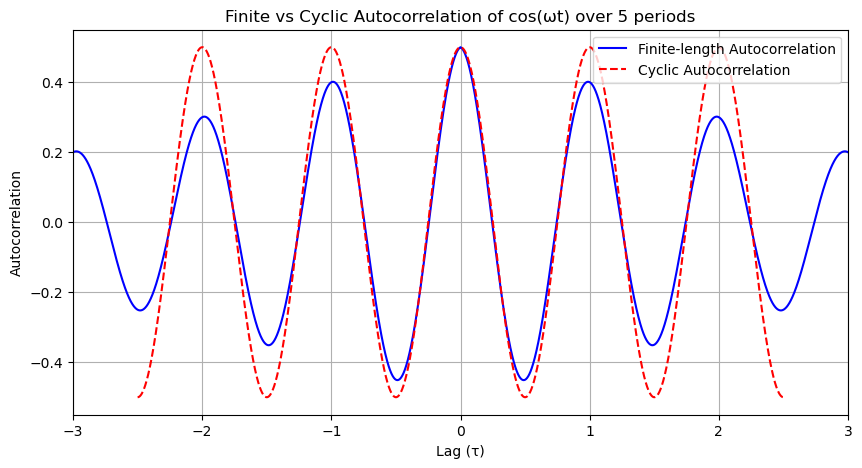

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
f = 1                     # 1 Hz cosine
omega = 2 * np.pi * f
T = 1 / f
num_periods = 5
fs = 1000                 # sampling frequency

# Time vector
# Time vector
t = np.linspace(0, num_periods*T, int(num_periods*T*fs), endpoint=False)
x = np.cos(omega * t)

N = len(x)

# --- Finite-length autocorrelation ---
Rxx_finite = np.correlate(x, x, mode='full') / N
lags_finite = np.arange(-N+1, N) / fs

# --- Cyclic (FFT-based) autocorrelation ---
X = np.fft.fft(x)
Rxx_cyclic = np.fft.ifft(np.abs(X)**2).real / N
# Shift zero lag to center for plotting
Rxx_cyclic = np.fft.fftshift(Rxx_cyclic)
lags_cyclic = np.arange(N) / fs - (N/2)/fs

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(lags_finite, Rxx_finite, label='Finite-length Autocorrelation', color='blue')
plt.plot(lags_cyclic, Rxx_cyclic, label='Cyclic Autocorrelation', color='red', linestyle='--')
plt.xlim(-3*T, 3*T)
plt.xlabel("Lag (τ)")
plt.ylabel("Autocorrelation")
plt.title("Finite vs Cyclic Autocorrelation of cos(ωt) over 5 periods")
plt.grid(True)
plt.legend()
plt.show()
